# Ghana Power System - 2030 Business as Usual Electricity Supply 
### Installed Capacity, Demand & Resource Profile for BAU / AEG Scenario Construction

Baseline diagnostic notebook for PyPSA-Ghana. Reports the **2024 as-built system**
only - existing generation fleet, 2024 demand profile, and weather-year resource
capacity factors. No 2030 optimization results (least-cost build-out, dispatch,
system cost, emissions, LMPs, curtailment) are included here; those are scenario
outputs and belong in the separate BAU and AEG notebooks built on top of this baseline.

**Workflow:** validate every number in Section 7 against Ghana Energy Commission
(and GRIDCo, where relevant) published 2024 figures before this baseline is used to
parameterize 2030 BAU and AEG runs.

Covers: network topology, existing (2024) capacity, 2024 demand profile
(peak, load factor, monthly, load-duration curve), weather-year resource capacity
factors (solar/wind), spatial resource pattern,
Energy Commission validation checklist, and 2024 population/electrification reference figures.

In [1]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

NETWORK_PATH = (
    "/data/PyPSA-GH/results/ghana_2030_bau/networks/elec_s_10_ec_lcopt_1hr.nc"
)
n = pypsa.Network(NETWORK_PATH)
print(n)
print(f"\nSnapshots: {n.snapshots[0]} -> {n.snapshots[-1]}  ({len(n.snapshots)} hours)")
print(f"Weather year: {n.meta['load_options']['weather_year']}")
print(f"Demand year represented: 2030 (BAU growth applied to 2024 shape)")
print(f"Objective value (solved): {n.objective:,.0f}")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1hr.nc has buses, carriers, generators, lines, loads, storage_units


PyPSA Network
Components:
 - Bus: 10
 - Carrier: 18
 - Generator: 43
 - Line: 13
 - Load: 10
 - StorageUnit: 12
Snapshots: 8784

Snapshots: 2024-01-01 00:00:00 -> 2024-12-31 23:00:00  (8784 hours)
Weather year: 2024
Demand year represented: 2030 (BAU growth applied to 2024 shape)
Objective value (solved): 1,127,856,441


## 0. Load network


In [2]:
NETWORK_PATH = (
    "/data/PyPSA-GH/results/ghana_2030_bau/networks/elec_s_10_ec_lcopt_1hr.nc"
)
n = pypsa.Network(NETWORK_PATH)
print(n)
print(f"\nSnapshots: {n.snapshots[0]} -> {n.snapshots[-1]}  ({len(n.snapshots)} hours)")
print(f"Weather / demand year: {n.meta['load_options']['weather_year']}")
print("\n(Reading p_nom / p_max_pu / loads_t.p_set only.)")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1hr.nc has buses, carriers, generators, lines, loads, storage_units


PyPSA Network
Components:
 - Bus: 10
 - Carrier: 18
 - Generator: 43
 - Line: 13
 - Load: 10
 - StorageUnit: 12
Snapshots: 8784

Snapshots: 2024-01-01 00:00:00 -> 2024-12-31 23:00:00  (8784 hours)
Weather / demand year: 2024

(Reading p_nom / p_max_pu / loads_t.p_set only.)


In [3]:
extendable = n.generators[n.generators.p_nom_extendable]
print(f"\nExtendable generators: {len(extendable)} of {len(n.generators)}")
print(
    f"Any capacity actually built? {(extendable.p_nom_opt > extendable.p_nom + 1).any()}"
)


Extendable generators: 29 of 43
Any capacity actually built? True


## 1. Network topology - buses & lines

10 clustered buses (k-means reduction of the full Ghana OSM transmission network),
12 lines at 330 kV. Bus coordinates are in WGS84 (EPSG:4326). Bus markers below are
sized by **existing (2024) capacity**

In [4]:
print(n.buses[["x", "y", "v_nom", "carrier"]])
print(
    f"\n{len(n.lines)} lines, {n.lines.s_nom_opt.sum():,.0f} MW total thermal rating (optimized)"
)
print(f"Original 2024 rating for comparison: {n.lines.s_nom.sum():,.0f} MW")
print(
    f"Line reinforcement added: {n.lines.s_nom_opt.sum() - n.lines.s_nom.sum():,.0f} MW"
)

              x          y  v_nom carrier
Bus                                      
GH0 0  0.329000   6.168791  330.0      AC
GH0 1 -1.886060   8.202800  330.0      AC
GH0 2 -1.789569   5.221475  330.0      AC
GH0 3 -1.484160  10.623460  330.0      AC
GH0 4 -1.459554   6.381200  330.0      AC
GH0 5 -0.740000   9.341000  330.0      AC
GH0 6 -2.324045   6.865164  330.0      AC
GH0 7 -0.321650   5.583410  330.0      AC
GH1 0  0.379200   7.240450  330.0      AC
GH2 0  0.339150   6.715850  330.0      AC

13 lines, 12,261 MW total thermal rating (optimized)
Original 2024 rating for comparison: 10,593 MW
Line reinforcement added: 1,668 MW


Total annual demand (2030 BAU)  : 31.34 TWh
Peak demand                     : 4,468 MW  (at 2024-10-24 19:00:00)
Average demand                  : 3,568 MW
Load factor                     : 79.9%
Minimum demand                  : 2,514 MW

Growth vs 2024 baseline:
  Annual demand growth : 34.8%
  Peak demand growth   : 27.1%
  CAGR (annual energy) : 5.10%  (2024->2030, 6 yrs)


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


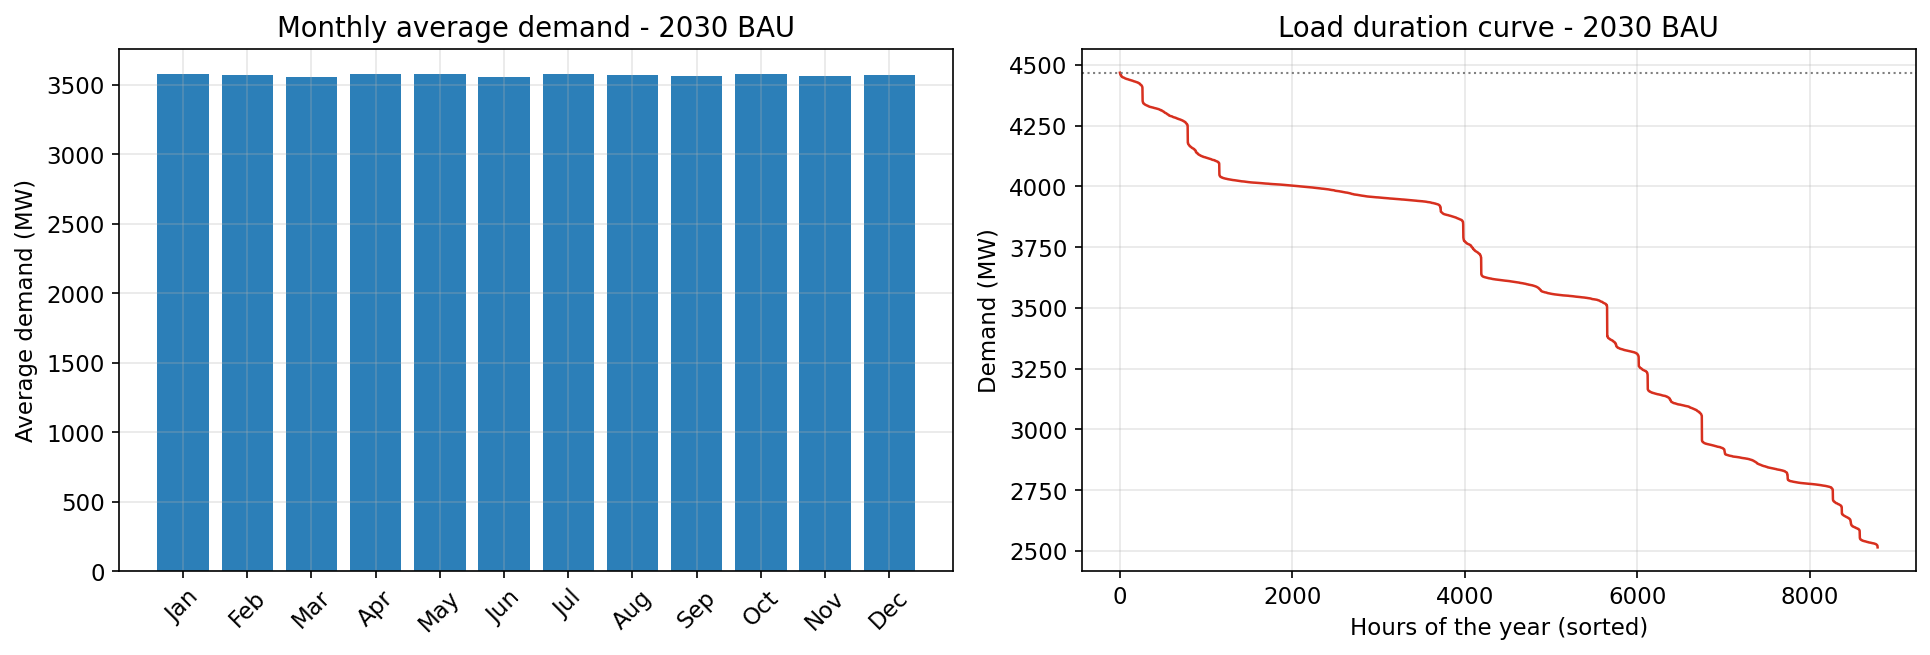

In [5]:
demand = n.loads_t.p_set.sum(axis=1)
total_demand_twh = demand.sum() / 1e6
peak_mw = demand.max()
peak_time = demand.idxmax()
mean_mw = demand.mean()
load_factor = mean_mw / peak_mw

print(f"Total annual demand (2030 BAU)  : {total_demand_twh:.2f} TWh")
print(f"Peak demand                     : {peak_mw:,.0f} MW  (at {peak_time})")
print(f"Average demand                  : {mean_mw:,.0f} MW")
print(f"Load factor                     : {load_factor:.1%}")
print(f"Minimum demand                  : {demand.min():,.0f} MW")

# Direct comparison against your 2024 baseline numbers
demand_2024_twh = 23.26  # from Section 8 of the baseline, EC-validated
peak_2024_mw = 3514.26
print(f"\nGrowth vs 2024 baseline:")
print(f"  Annual demand growth : {(total_demand_twh/demand_2024_twh - 1):.1%}")
print(f"  Peak demand growth   : {(peak_mw/peak_2024_mw - 1):.1%}")
print(
    f"  CAGR (annual energy) : {(total_demand_twh/demand_2024_twh)**(1/6) - 1:.2%}  (2024->2030, 6 yrs)"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
monthly = demand.resample("ME").mean()
axes[0].bar(monthly.index.strftime("%b"), monthly.values, color="#2c7fb8")
axes[0].set_ylabel("Average demand (MW)")
axes[0].set_title("Monthly average demand - 2030 BAU")
axes[0].tick_params(axis="x", rotation=45)

duration = np.sort(demand.values)[::-1]
hours = np.arange(1, len(duration) + 1)
axes[1].plot(hours, duration, color="#d7301f", lw=1.2)
axes[1].axhline(peak_mw, color="gray", ls=":", lw=1)
axes[1].set_xlabel("Hours of the year (sorted)")
axes[1].set_ylabel("Demand (MW)")
axes[1].set_title("Load duration curve - 2030 BAU")

plt.tight_layout()
plt.savefig("fig2_bau2030_demand.png", bbox_inches="tight")
plt.show()

In [6]:
solar_gens = n.generators[n.generators.carrier == "solar"].index
onwind_gens = n.generators[n.generators.carrier == "onwind"].index

resource_cf_2030 = {
    "solar": n.generators_t.p_max_pu[solar_gens].mean().mean(),
    "onwind": n.generators_t.p_max_pu[onwind_gens].mean().mean(),
}
print("2030 BAU weather-year resource CF (should match 2024 baseline exactly):")
print(pd.Series(resource_cf_2030).round(3))
print("\nIf these differ from the 2024 baseline (~0.622 solar post-SARAH-correction,")
print("~0.061 onwind pre-fix / ~0.13 target post-fix), you're running against a")
print(
    "different weather-year cutout or the correction factor wasn't carried into BAU config."
)

2030 BAU weather-year resource CF (should match 2024 baseline exactly):
solar     0.180
onwind    0.096
dtype: float64

If these differ from the 2024 baseline (~0.622 solar post-SARAH-correction,
~0.061 onwind pre-fix / ~0.13 target post-fix), you're running against a
different weather-year cutout or the correction factor wasn't carried into BAU config.


2030 BAU generation mix (GWh):
carrier
CCGT             12815.0
solar            10098.0
hydro             7373.0
OCGT              1056.0
biomass              1.0
battery              0.0
load shedding        0.0
offwind-ac           0.0
offwind-dc           0.0
onwind               0.0
ror                  0.0
dtype: float64

Total generation: 31,344 GWh
vs total demand:  31,344 GWh  (difference = losses/curtailment/shedding)

Grouped share (%):
carrier
thermal          44.26
solar            32.22
hydro            23.52
battery           0.00
load shedding     0.00
wind              0.00
dtype: float64


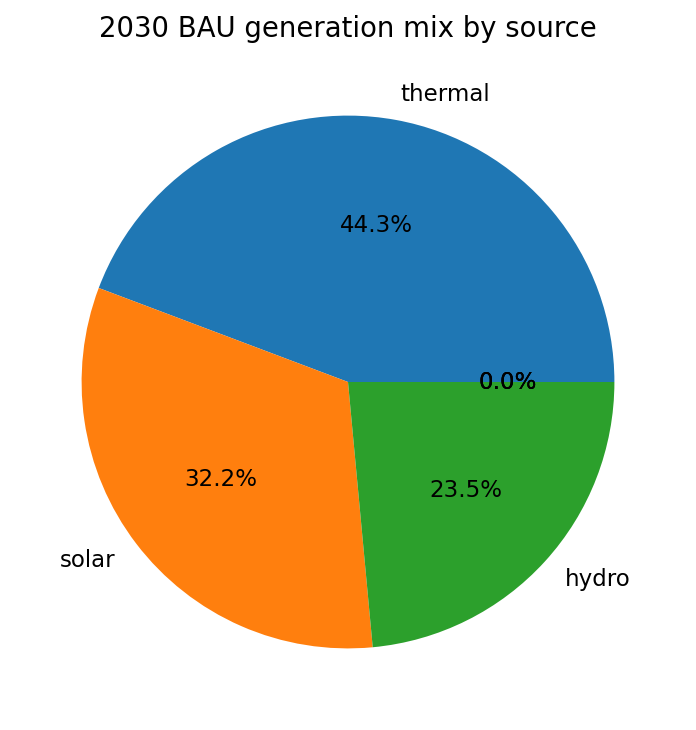

In [7]:
gen_by_carrier_gwh = (
    n.generators_t.p.T.groupby(n.generators.carrier)
    .sum()
    .T.sum()
    .add(
        n.storage_units_t.p_dispatch.T.groupby(n.storage_units.carrier).sum().T.sum(),
        fill_value=0,
    )
) / 1e3  # MWh -> GWh

gen_share_pct = (gen_by_carrier_gwh / gen_by_carrier_gwh.sum() * 100).round(2)

carrier_map = {
    "CCGT": "thermal",
    "OCGT": "thermal",
    "biomass": "thermal",
    "hydro": "hydro",
    "ror": "hydro",
    "solar": "solar",
    "onwind": "wind",
    "offwind-ac": "wind",
    "offwind-dc": "wind",
    "load shedding": "load shedding",
}
gen_share_grouped = (
    gen_share_pct.rename(index=carrier_map)
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
)

print("2030 BAU generation mix (GWh):")
print(gen_by_carrier_gwh.round(0).sort_values(ascending=False))
print(f"\nTotal generation: {gen_by_carrier_gwh.sum():,.0f} GWh")
print(
    f"vs total demand:  {total_demand_twh*1000:,.0f} GWh  (difference = losses/curtailment/shedding)"
)
print("\nGrouped share (%):")
print(gen_share_grouped.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
gen_share_grouped.plot.pie(ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("2030 BAU generation mix by source")
plt.tight_layout()
plt.savefig("fig5_2030_gen_mix.png", bbox_inches="tight")
plt.show()

System-average marginal price (2030 BAU): $52.50/MWh
Min hourly price: $0.02/MWh
Max hourly price: $7,902.68/MWh
Load-weighted average price: $52.53/MWh


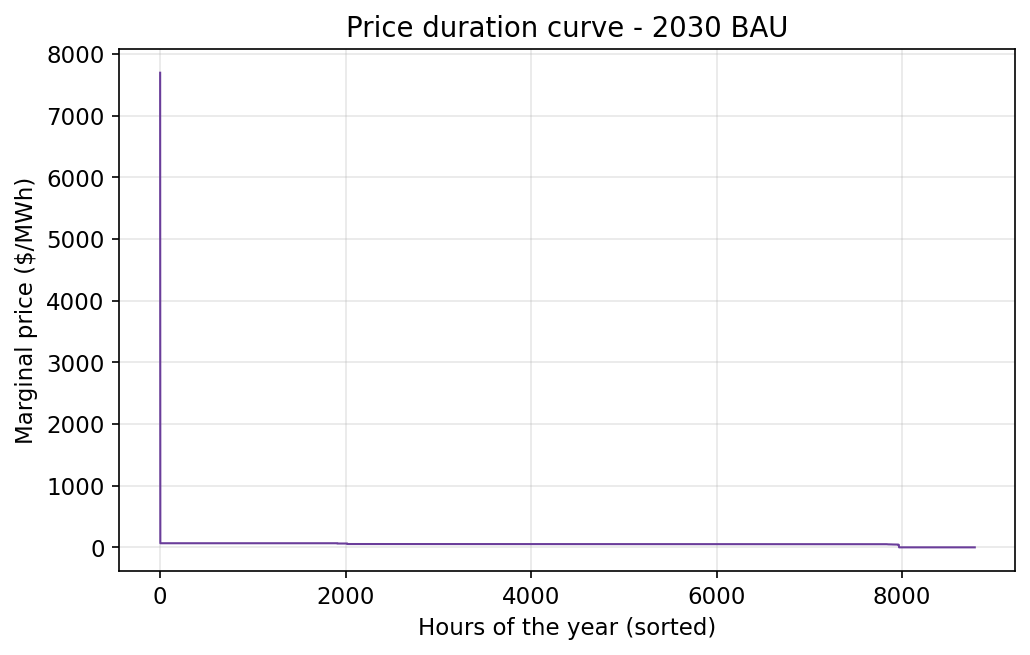

In [8]:
marginal_price = n.buses_t.marginal_price  # $/MWh, per bus per hour
system_avg_price = marginal_price.mean().mean()
national_hourly_price = marginal_price.mean(
    axis=1
)  # simple bus-average per hour; weight by load if you want a true system price

print(f"System-average marginal price (2030 BAU): ${system_avg_price:,.2f}/MWh")
print(f"Min hourly price: ${national_hourly_price.min():,.2f}/MWh")
print(f"Max hourly price: ${national_hourly_price.max():,.2f}/MWh")

# Load-weighted average price is more meaningful than a flat bus average
load_weights = n.loads_t.p_set
bus_of_load = n.loads.bus
price_at_load_bus = marginal_price[bus_of_load.reindex(load_weights.columns).values]
price_at_load_bus.columns = load_weights.columns
load_weighted_price = (price_at_load_bus * load_weights).sum(axis=1) / load_weights.sum(
    axis=1
)
print(f"Load-weighted average price: ${load_weighted_price.mean():,.2f}/MWh")

fig, ax = plt.subplots(figsize=(7, 4.5))
duration_price = np.sort(load_weighted_price.values)[::-1]
ax.plot(np.arange(1, len(duration_price) + 1), duration_price, color="#6a3d9a", lw=1)
ax.set_xlabel("Hours of the year (sorted)")
ax.set_ylabel("Marginal price ($/MWh)")
ax.set_title("Price duration curve - 2030 BAU")
plt.tight_layout()
plt.savefig("fig6_2030_price_duration.png", bbox_inches="tight")
plt.show()

            2024 existing (MW)  2030 BAU optimal (MW)  \
carrier                                                 
solar                    133.0                 6495.5   
OCGT                    2100.0                 2100.0   
CCGT                    1932.0                 1932.0   
hydro                   1584.0                 1584.0   
biomass                    0.1                    0.1   
ror                        0.0                    0.0   
onwind                     0.0                    0.0   
offwind-ac                 0.0                    0.0   
offwind-dc                 0.0                    0.0   

            New build 2024->2030 (MW)  % growth  
carrier                                          
solar                          6362.5    4783.9  
OCGT                              0.0       0.0  
CCGT                              0.0       0.0  
hydro                             0.0       0.0  
biomass                           0.0       0.0  
ror                   

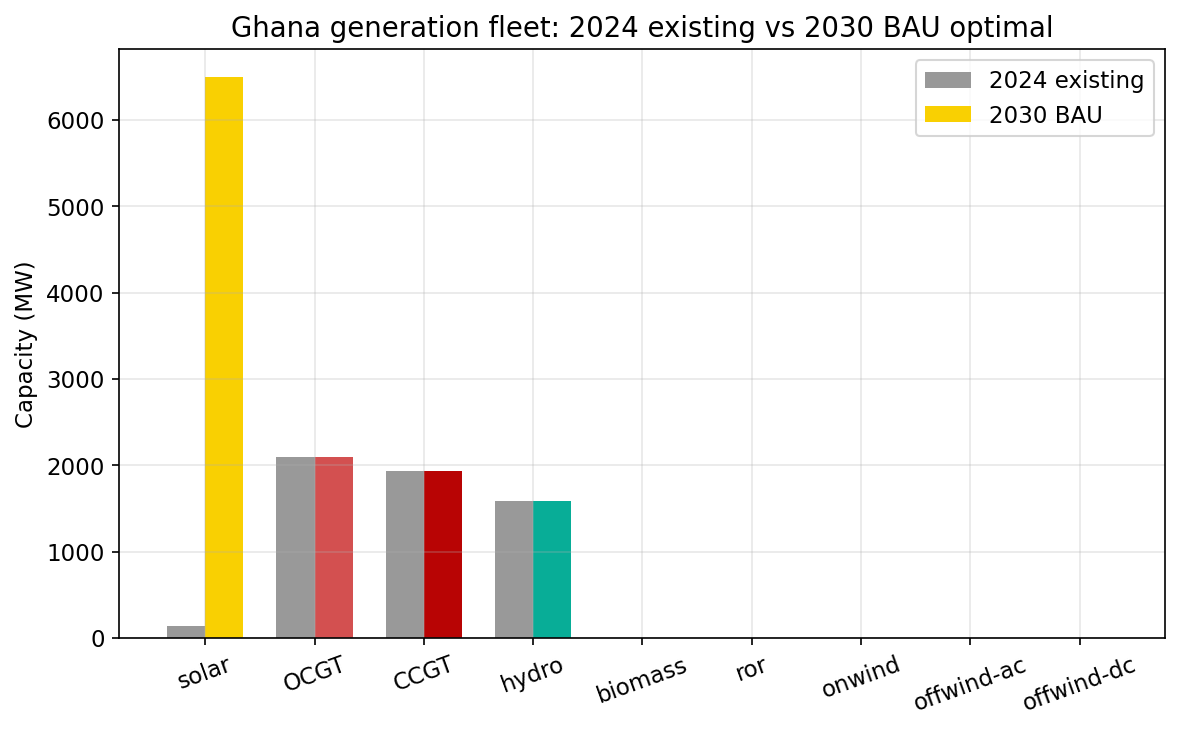

In [10]:
cap_2030 = n.generators.groupby("carrier").p_nom_opt.sum()
cap_2030["hydro"] = (
    n.storage_units.p_nom_opt.sum()
    if "p_nom_opt" in n.storage_units.columns
    else n.storage_units.p_nom.sum()
)
cap_2030 = cap_2030.drop("load shedding", errors="ignore")
cap_2030 = cap_2030[cap_2030 > 0].sort_values(ascending=False)

cap_2024 = n.generators.groupby(
    "carrier"
).p_nom.sum()  # pre-optimization = as-built 2024/25 fleet
cap_2024["hydro"] = n.storage_units.p_nom.sum()
cap_2024 = cap_2024.reindex(cap_2030.index).fillna(0)

buildout = pd.DataFrame(
    {
        "2024 existing (MW)": cap_2024,
        "2030 BAU optimal (MW)": cap_2030,
        "New build 2024->2030 (MW)": cap_2030 - cap_2024,
    }
)
buildout["% growth"] = (
    buildout["2030 BAU optimal (MW)"] / buildout["2024 existing (MW)"] - 1
) * 100
print(buildout.round(1))
print(f"\nTotal 2024 capacity : {cap_2024.sum():,.0f} MW")
print(f"Total 2030 capacity : {cap_2030.sum():,.0f} MW")
print(f"Total new build     : {(cap_2030.sum() - cap_2024.sum()):,.0f} MW")

colors = {
    "solar": "#f9d002",
    "onwind": "#235ebc",
    "offwind-ac": "#6895dd",
    "offwind-dc": "#74c6f2",
    "CCGT": "#b80404",
    "OCGT": "#d35050",
    "hydro": "#08ad97",
}

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(buildout))
width = 0.35
ax.bar(
    x - width / 2,
    buildout["2024 existing (MW)"],
    width,
    label="2024 existing",
    color="#999999",
)
ax.bar(
    x + width / 2,
    buildout["2030 BAU optimal (MW)"],
    width,
    label="2030 BAU",
    color=[colors.get(c, "gray") for c in buildout.index],
)
ax.set_xticks(x)
ax.set_xticklabels(buildout.index, rotation=20)
ax.set_ylabel("Capacity (MW)")
ax.set_title("Ghana generation fleet: 2024 existing vs 2030 BAU optimal")
ax.legend()
plt.tight_layout()
plt.savefig("fig3_2030_capacity_buildout.png", bbox_inches="tight")
plt.show()

In [11]:
solar_gens = n.generators[n.generators.carrier == "solar"].index
onwind_gens = n.generators[n.generators.carrier == "onwind"].index

resource_cf_2030 = {
    "solar": n.generators_t.p_max_pu[solar_gens].mean().mean(),
    "onwind": n.generators_t.p_max_pu[onwind_gens].mean().mean(),
}
print("2030 BAU weather-year resource CF (should match 2024 baseline exactly):")
print(pd.Series(resource_cf_2030).round(3))
print("\nIf these differ from the 2024 baseline (~0.622 solar post-SARAH-correction,")
print("~0.061 onwind pre-fix / ~0.13 target post-fix), you're running against a")
print(
    "different weather-year cutout or the correction factor wasn't carried into BAU config."
)

2030 BAU weather-year resource CF (should match 2024 baseline exactly):
solar     0.180
onwind    0.096
dtype: float64

If these differ from the 2024 baseline (~0.622 solar post-SARAH-correction,
~0.061 onwind pre-fix / ~0.13 target post-fix), you're running against a
different weather-year cutout or the correction factor wasn't carried into BAU config.


2030 BAU generation mix (GWh):
carrier
CCGT             12815.0
solar            10098.0
hydro             7373.0
OCGT              1056.0
biomass              1.0
battery              0.0
load shedding        0.0
offwind-ac           0.0
offwind-dc           0.0
onwind               0.0
ror                  0.0
dtype: float64

Total generation: 31,344 GWh
vs total demand:  31,344 GWh  (difference = losses/curtailment/shedding)

Grouped share (%):
carrier
thermal          44.26
solar            32.22
hydro            23.52
battery           0.00
load shedding     0.00
wind              0.00
dtype: float64


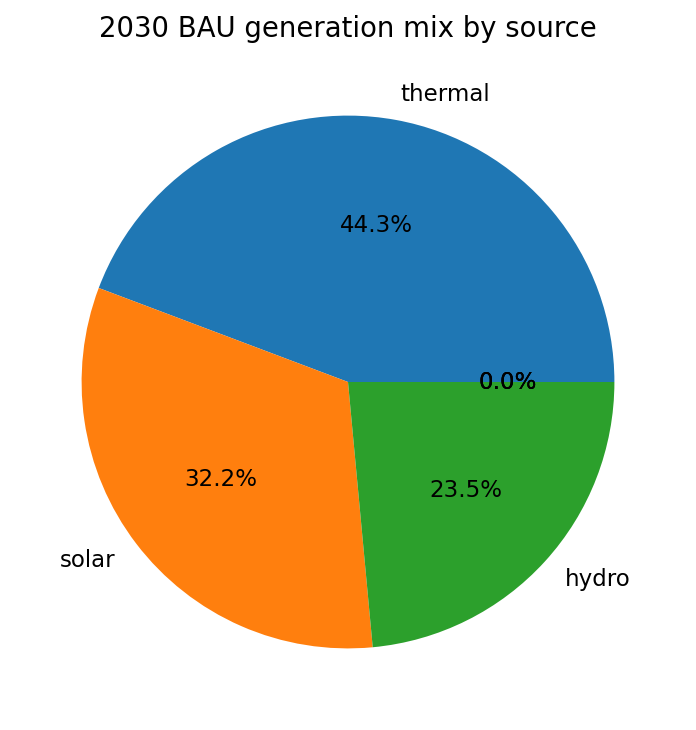

In [12]:
gen_by_carrier_gwh = (
    n.generators_t.p.T.groupby(n.generators.carrier)
    .sum()
    .T.sum()
    .add(
        n.storage_units_t.p_dispatch.T.groupby(n.storage_units.carrier).sum().T.sum(),
        fill_value=0,
    )
) / 1e3  # MWh -> GWh

gen_share_pct = (gen_by_carrier_gwh / gen_by_carrier_gwh.sum() * 100).round(2)

carrier_map = {
    "CCGT": "thermal",
    "OCGT": "thermal",
    "biomass": "thermal",
    "hydro": "hydro",
    "ror": "hydro",
    "solar": "solar",
    "onwind": "wind",
    "offwind-ac": "wind",
    "offwind-dc": "wind",
    "load shedding": "load shedding",
}
gen_share_grouped = (
    gen_share_pct.rename(index=carrier_map)
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
)

print("2030 BAU generation mix (GWh):")
print(gen_by_carrier_gwh.round(0).sort_values(ascending=False))
print(f"\nTotal generation: {gen_by_carrier_gwh.sum():,.0f} GWh")
print(
    f"vs total demand:  {total_demand_twh*1000:,.0f} GWh  (difference = losses/curtailment/shedding)"
)
print("\nGrouped share (%):")
print(gen_share_grouped.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
gen_share_grouped.plot.pie(ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("2030 BAU generation mix by source")
plt.tight_layout()
plt.savefig("fig5_2030_gen_mix.png", bbox_inches="tight")
plt.show()

System-average marginal price (2030 BAU): $52.50/MWh
Min hourly price: $0.02/MWh
Max hourly price: $7,902.68/MWh
Load-weighted average price: $52.53/MWh


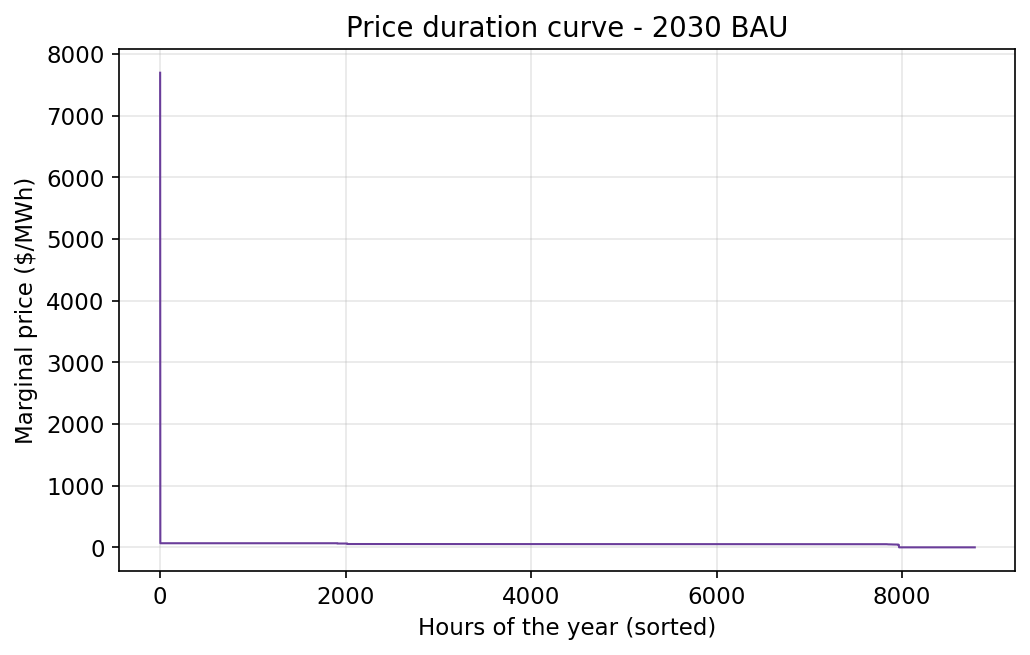

In [13]:
marginal_price = n.buses_t.marginal_price  # $/MWh, per bus per hour
system_avg_price = marginal_price.mean().mean()
national_hourly_price = marginal_price.mean(
    axis=1
)  # simple bus-average per hour; weight by load if you want a true system price

print(f"System-average marginal price (2030 BAU): ${system_avg_price:,.2f}/MWh")
print(f"Min hourly price: ${national_hourly_price.min():,.2f}/MWh")
print(f"Max hourly price: ${national_hourly_price.max():,.2f}/MWh")

# Load-weighted average price is more meaningful than a flat bus average
load_weights = n.loads_t.p_set
bus_of_load = n.loads.bus
price_at_load_bus = marginal_price[bus_of_load.reindex(load_weights.columns).values]
price_at_load_bus.columns = load_weights.columns
load_weighted_price = (price_at_load_bus * load_weights).sum(axis=1) / load_weights.sum(
    axis=1
)
print(f"Load-weighted average price: ${load_weighted_price.mean():,.2f}/MWh")

fig, ax = plt.subplots(figsize=(7, 4.5))
duration_price = np.sort(load_weighted_price.values)[::-1]
ax.plot(np.arange(1, len(duration_price) + 1), duration_price, color="#6a3d9a", lw=1)
ax.set_xlabel("Hours of the year (sorted)")
ax.set_ylabel("Marginal price ($/MWh)")
ax.set_title("Price duration curve - 2030 BAU")
plt.tight_layout()
plt.savefig("fig6_2030_price_duration.png", bbox_inches="tight")
plt.show()

In [14]:
# Capital cost of new build only (2030 optimal minus 2024 existing, valued at each tech's overnight cost)
capex_new = (
    (n.generators.p_nom_opt - n.generators.p_nom).clip(lower=0)
    * n.generators.capital_cost
).sum()
capex_new += (
    (
        (n.storage_units.p_nom_opt - n.storage_units.p_nom).clip(lower=0)
        * n.storage_units.capital_cost
    ).sum()
    if "p_nom_opt" in n.storage_units.columns
    else 0
)
capex_new += (
    (n.lines.s_nom_opt - n.lines.s_nom).clip(lower=0) * n.lines.capital_cost
).sum()

# Operational cost: fuel + VOM, from dispatch x marginal_cost
opex = (n.generators_t.p * n.generators.marginal_cost).sum().sum()

total_system_cost = n.objective + n.objective_constant
print(f"New-build capital cost (annualized): ${capex_new:,.0f}")
print(f"Operational cost (fuel + VOM):        ${opex:,.0f}")
print(f"Total system cost (objective):        ${total_system_cost:,.0f}")
print(
    f"Cost per MWh served:                  ${total_system_cost / (gen_by_carrier_gwh.sum()*1e3):,.2f}/MWh"
)

# marginal cost by carrier - useful to sanity check fuel price assumptions
print("\nMarginal cost by carrier ($/MWh):")
print(
    n.generators.groupby("carrier")
    .marginal_cost.mean()
    .round(2)
    .sort_values(ascending=False)
)

New-build capital cost (annualized): $368,550,079
Operational cost (fuel + VOM):        $761,311,869
Total system cost (objective):        $1,336,404,025
Cost per MWh served:                  $42.64/MWh

Marginal cost by carrier ($/MWh):
carrier
load shedding    100000.01
OCGT                 66.67
CCGT                 53.90
biomass              17.09
onwind                0.03
offwind-ac            0.02
offwind-dc            0.02
solar                 0.02
ror                   0.01
Name: marginal_cost, dtype: float64


In [ ]:
# Capital cost of new build only (2030 optimal minus 2024 existing, valued at each tech's overnight cost)
capex_new = (
    (n.generators.p_nom_opt - n.generators.p_nom).clip(lower=0)
    * n.generators.capital_cost
).sum()
capex_new += (
    (
        (n.storage_units.p_nom_opt - n.storage_units.p_nom).clip(lower=0)
        * n.storage_units.capital_cost
    ).sum()
    if "p_nom_opt" in n.storage_units.columns
    else 0
)
capex_new += (
    (n.lines.s_nom_opt - n.lines.s_nom).clip(lower=0) * n.lines.capital_cost
).sum()

# Operational cost: fuel + VOM, from dispatch x marginal_cost
opex = (n.generators_t.p * n.generators.marginal_cost).sum().sum()

total_system_cost = n.objective + n.objective_constant
print(f"New-build capital cost (annualized): ${capex_new:,.0f}")
print(f"Operational cost (fuel + VOM):        ${opex:,.0f}")
print(f"Total system cost (objective):        ${total_system_cost:,.0f}")
print(
    f"Cost per MWh served:                  ${total_system_cost / (gen_by_carrier_gwh.sum()*1e3):,.2f}/MWh"
)

# marginal cost by carrier - useful to sanity check fuel price assumptions
print("\nMarginal cost by carrier ($/MWh):")
print(
    n.generators.groupby("carrier")
    .marginal_cost.mean()
    .round(2)
    .sort_values(ascending=False)
)

In [17]:
carriers = n.carriers
co2_intensity = carriers["co2_emissions"]  # tCO2 / MWh_thermal

fuel_consumption = n.generators_t.p.div(
    n.generators.efficiency.replace(0, np.nan), axis=1
)
emissions_by_gen = fuel_consumption.mul(n.generators.carrier.map(co2_intensity), axis=1)
emissions_by_carrier_t = emissions_by_gen.sum().groupby(n.generators.carrier).sum()
emissions_by_carrier_t = emissions_by_carrier_t[emissions_by_carrier_t > 0].sort_values(
    ascending=False
)

total_emissions_mt = emissions_by_carrier_t.sum() / 1e6
total_gen_gwh = gen_by_carrier_gwh.sum()
emission_intensity = (emissions_by_carrier_t.sum() * 1e3) / (
    total_gen_gwh * 1e3
)  # gCO2/kWh

print("CO2 emissions by carrier (tonnes):")
print(emissions_by_carrier_t.round(0))
print(f"\nTotal system emissions: {total_emissions_mt:.3f} Mt CO2")
print(f"Emission intensity: {emission_intensity:.1f} gCO2/kWh")

# Cross-check against your CO2 GlobalConstraint if one is set
if len(n.global_constraints):
    print("\nGlobalConstraint(s) in network:")
    print(n.global_constraints)

CO2 emissions by carrier (tonnes):
carrier
CCGT    4792734.0
OCGT     506377.0
dtype: float64

Total system emissions: 5.299 Mt CO2
Emission intensity: 169.1 gCO2/kWh


In [16]:
vre_carriers = ["solar", "onwind", "offwind-ac", "offwind-dc"]
vre_gens = n.generators[n.generators.carrier.isin(vre_carriers)].index

available_mwh = (
    n.generators_t.p_max_pu[vre_gens] * n.generators.loc[vre_gens, "p_nom_opt"]
).sum()
dispatched_mwh = n.generators_t.p[vre_gens].sum()
curtailed_mwh = (available_mwh - dispatched_mwh).clip(lower=0)

curtailment_by_carrier = pd.DataFrame(
    {
        "available_GWh": available_mwh.groupby(
            n.generators.loc[vre_gens, "carrier"]
        ).sum()
        / 1e3,
        "dispatched_GWh": dispatched_mwh.groupby(
            n.generators.loc[vre_gens, "carrier"]
        ).sum()
        / 1e3,
        "curtailed_GWh": curtailed_mwh.groupby(
            n.generators.loc[vre_gens, "carrier"]
        ).sum()
        / 1e3,
    }
)
curtailment_by_carrier["curtailment_%"] = (
    curtailment_by_carrier["curtailed_GWh"]
    / curtailment_by_carrier["available_GWh"]
    * 100
).round(2)

print(curtailment_by_carrier.round(1))

            available_GWh  dispatched_GWh  curtailed_GWh  curtailment_%
carrier                                                                
offwind-ac            0.0             0.0            0.0           36.3
offwind-dc            0.0             0.0            0.0           38.4
onwind                0.0             0.0            0.0           30.1
solar             10430.5         10098.4          332.1            3.2


In [18]:
achieved_cf = (
    (
        n.generators_t.p[vre_gens].sum()
        / (n.generators.loc[vre_gens, "p_nom_opt"] * len(n.snapshots))
    )
    .groupby(n.generators.loc[vre_gens, "carrier"])
    .mean()
)
resource_cf_series = pd.Series(resource_cf_2030)

cf_compare = pd.DataFrame(
    {
        "Resource CF (ceiling)": resource_cf_series,
        "Achieved dispatch CF": achieved_cf.reindex(resource_cf_series.index),
    }
)
cf_compare["Utilization %"] = (
    cf_compare["Achieved dispatch CF"] / cf_compare["Resource CF (ceiling)"] * 100
).round(1)
print(cf_compare.round(3))

        Resource CF (ceiling)  Achieved dispatch CF  Utilization %
solar                   0.180                 0.159           88.7
onwind                  0.096                 0.065           68.3


In [19]:
validation_2030 = pd.DataFrame(
    {
        "model_value": {
            "Total installed capacity (MW)": cap_2030.sum(),
            "Solar installed capacity (MW)": cap_2030.get("solar", 0),
            "Onwind installed capacity (MW)": cap_2030.get("onwind", 0),
            "Hydro installed capacity (MW)": cap_2030.get("hydro", 0),
            "Thermal (CCGT+OCGT) installed capacity (MW)": cap_2030.get("CCGT", 0)
            + cap_2030.get("OCGT", 0),
            "Peak demand (MW)": peak_mw,
            "Annual demand (TWh)": total_demand_twh,
            "CO2 emissions (Mt)": total_emissions_mt,
        },
        "ec_2030_target": {
            # Fill from EC 2024 Outlook / GEMP 2020-2030 published 2030 projections
            "Total installed capacity (MW)": np.nan,
            "Solar installed capacity (MW)": np.nan,
            "Onwind installed capacity (MW)": np.nan,
            "Hydro installed capacity (MW)": 1584.00,  # no new large hydro assumed in most BAU tracks
            "Thermal (CCGT+OCGT) installed capacity (MW)": np.nan,
            "Peak demand (MW)": np.nan,
            "Annual demand (TWh)": np.nan,
            "CO2 emissions (Mt)": np.nan,
        },
    }
)
validation_2030["diff_pct"] = (
    (validation_2030["model_value"] - validation_2030["ec_2030_target"])
    / validation_2030["ec_2030_target"]
    * 100
)
print(validation_2030.round(2))

                                             model_value  ec_2030_target  \
Total installed capacity (MW)                   12111.68             NaN   
Solar installed capacity (MW)                    6495.53             NaN   
Onwind installed capacity (MW)                      0.00             NaN   
Hydro installed capacity (MW)                    1584.00          1584.0   
Thermal (CCGT+OCGT) installed capacity (MW)      4032.00             NaN   
Peak demand (MW)                                 4467.90             NaN   
Annual demand (TWh)                                31.34             NaN   
CO2 emissions (Mt)                                  5.30             NaN   

                                             diff_pct  
Total installed capacity (MW)                     NaN  
Solar installed capacity (MW)                     NaN  
Onwind installed capacity (MW)                    NaN  
Hydro installed capacity (MW)                     0.0  
Thermal (CCGT+OCGT) installed capac

In [20]:
pop_2024 = 34.4e6
pop_growth_rate = 0.021  # Ghana Statistical Service ~2.1%/yr — adjust to your source
pop_2030 = pop_2024 * (1 + pop_growth_rate) ** 6

elec_2024 = 0.89
elec_2030 = 0.95  # National Electrification Scheme / Energy Compact target — adjust to your source

connected_pop_2030 = pop_2030 * elec_2030
per_capita_kwh_2030 = total_demand_twh * 1e6 * 1000 / connected_pop_2030

print(f"2030 population (projected)         : {pop_2030/1e6:.1f} million")
print(f"2030 electrification rate (target)  : {elec_2030:.1%}")
print(f"2030 connected population            : {connected_pop_2030/1e6:.1f} million")
print(
    f"Model's 2030 demand                  : {total_demand_twh:.2f} TWh -> "
    f"{per_capita_kwh_2030:,.0f} kWh/connected-person/yr"
)
print(
    f"\n2024 baseline per-capita was ~{500}-{550} kWh/yr population-wide; "
    f"check 2030 per-capita growth is consistent with your BAU per-capita growth assumption, "
    f"not just population growth."
)

2030 population (projected)         : 39.0 million
2030 electrification rate (target)  : 95.0%
2030 connected population            : 37.0 million
Model's 2030 demand                  : 31.34 TWh -> 847 kWh/connected-person/yr

2024 baseline per-capita was ~500-550 kWh/yr population-wide; check 2030 per-capita growth is consistent with your BAU per-capita growth assumption, not just population growth.


In [21]:
print("=" * 60)
print("GHANA 2030 BAU — SUMMARY")
print("=" * 60)
print(
    f"Peak demand          : {peak_mw:,.0f} MW  ({(peak_mw/peak_2024_mw-1):+.1%} vs 2024)"
)
print(
    f"Annual demand         : {total_demand_twh:.2f} TWh  ({(total_demand_twh/demand_2024_twh-1):+.1%} vs 2024)"
)
print(
    f"Total capacity        : {cap_2030.sum():,.0f} MW  ({(cap_2030.sum()/cap_2024.sum()-1):+.1%} vs 2024)"
)
print(f"New build             : {(cap_2030.sum()-cap_2024.sum()):,.0f} MW")
print(f"Generation mix        : {dict(gen_share_grouped.round(1))}")
print(
    f"System cost            : ${total_system_cost:,.0f}  (${total_system_cost/(gen_by_carrier_gwh.sum()*1e3):.2f}/MWh)"
)
print(f"Avg marginal price     : ${system_avg_price:,.2f}/MWh")
print(
    f"CO2 emissions          : {total_emissions_mt:.3f} Mt  ({emission_intensity:.1f} gCO2/kWh)"
)
print(f"VRE curtailment        : {curtailment_by_carrier['curtailment_%'].to_dict()}")

GHANA 2030 BAU — SUMMARY
Peak demand          : 4,468 MW  (+27.1% vs 2024)
Annual demand         : 31.34 TWh  (+34.8% vs 2024)
Total capacity        : 12,112 MW  (+110.7% vs 2024)
New build             : 6,363 MW
Generation mix        : {'thermal': 44.3, 'solar': 32.2, 'hydro': 23.5, 'battery': 0.0, 'load shedding': 0.0, 'wind': 0.0}
System cost            : $1,336,404,025  ($42.64/MWh)
Avg marginal price     : $52.50/MWh
CO2 emissions          : 5.299 Mt  (169.1 gCO2/kWh)
VRE curtailment        : {'offwind-ac': 36.33, 'offwind-dc': 38.41, 'onwind': 30.14, 'solar': 3.18}


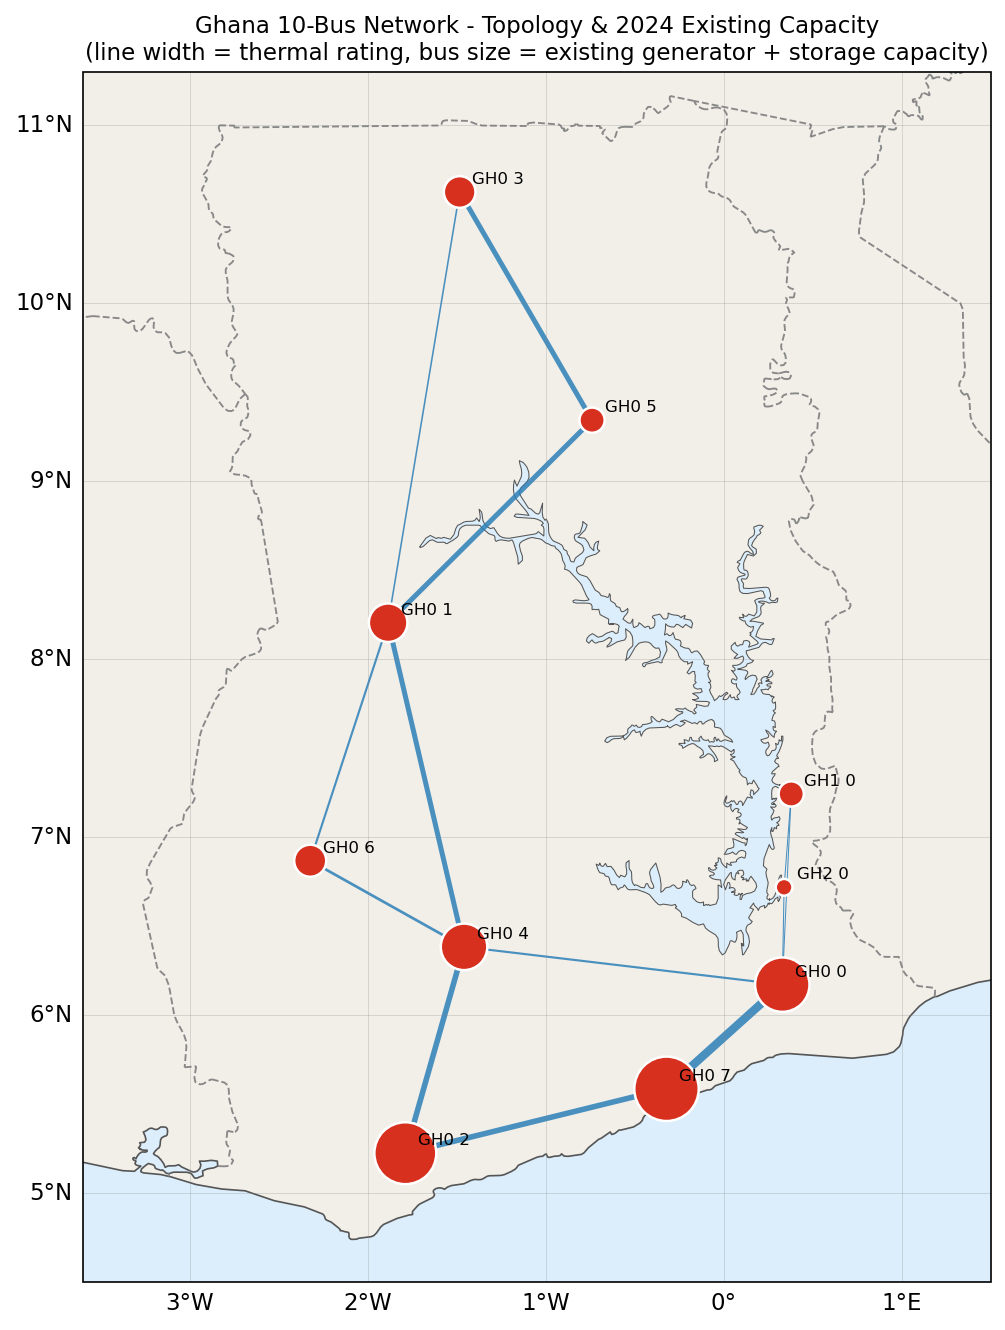

In [22]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(8, 9), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-3.6, 1.5, 4.5, 11.3], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#f2efe9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dceefb", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#555555")
ax.add_feature(cfeature.BORDERS, linewidth=0.9, linestyle="--", edgecolor="#888888")
ax.add_feature(cfeature.LAKES, facecolor="#dceefb", edgecolor="#555555", linewidth=0.5)

# transmission lines, weighted by thermal rating
for _, ln in n.lines.iterrows():
    b0, b1 = n.buses.loc[ln.bus0], n.buses.loc[ln.bus1]
    lw = 0.5 + 3.5 * (ln.s_nom / n.lines.s_nom.max()) if n.lines.s_nom.max() > 0 else 1
    ax.plot(
        [b0.x, b1.x],
        [b0.y, b1.y],
        color="#2c7fb8",
        lw=lw,
        alpha=0.85,
        transform=ccrs.PlateCarree(),
        zorder=2,
    )

# bus markers sized by EXISTING (2024) capacity (generators + storage)
cap = (
    n.generators.groupby("bus")
    .p_nom.sum()
    .add(n.storage_units.groupby("bus").p_nom.sum(), fill_value=0)
)
sizes = 30 + 0.35 * cap.reindex(n.buses.index).fillna(0)

sc = ax.scatter(
    n.buses.x,
    n.buses.y,
    s=sizes,
    c="#d7301f",
    edgecolor="white",
    linewidth=1.2,
    zorder=3,
    transform=ccrs.PlateCarree(),
)
for name, row in n.buses.iterrows():
    ax.annotate(
        name,
        (row.x, row.y),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
        transform=ccrs.PlateCarree(),
    )

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
gl.top_labels = gl.right_labels = False

ax.set_title(
    "Ghana 10-Bus Network - Topology & 2024 Existing Capacity\n"
    "(line width = thermal rating, bus size = existing generator + storage capacity)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("fig1_network_map_baseline.png", bbox_inches="tight")
plt.show()

## 2. 2024 baseline demand - profile, peak, load duration

`loads_t.p_set` holds the synthetic hourly demand assigned to each bus for the full
2024 weather year (GEGIS-based, scaled to national totals). This is the demand
baseline that both BAU and AEG will grow forward from 2030 — validate the peak and
annual total against GRIDCo/Energy Commission figures in Section 7 before using it.

In [ ]:
demand = n.loads_t.p_set.sum(axis=1)  # MW, national total, hourly
total_demand_twh = demand.sum() / 1e6
peak_mw = demand.max()
peak_time = demand.idxmax()
mean_mw = demand.mean()
load_factor = mean_mw / peak_mw

print(f"Total annual demand         : {total_demand_twh:.2f} TWh")
print(f"Peak demand                 : {peak_mw:,.0f} MW  (at {peak_time})")
print(f"Average demand              : {mean_mw:,.0f} MW")
print(f"Load factor                 : {load_factor:.1%}")
print(f"Minimum demand               : {demand.min():,.0f} MW")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

monthly = demand.resample("ME").mean()
axes[0].bar(monthly.index.strftime("%b"), monthly.values, color="#2c7fb8")
axes[0].set_ylabel("Average demand (MW)")
axes[0].set_title("Monthly average demand - 2024 baseline")
axes[0].tick_params(axis="x", rotation=45)

duration = np.sort(demand.values)[::-1]
hours = np.arange(1, len(duration) + 1)
axes[1].plot(hours, duration, color="#d7301f", lw=1.2)
axes[1].axhline(peak_mw, color="gray", ls=":", lw=1)
axes[1].set_xlabel("Hours of the year (sorted)")
axes[1].set_ylabel("Demand (MW)")
axes[1].set_title("Load duration curve - 2024 baseline")

plt.tight_layout()
plt.savefig("fig2_baseline_demand.png", bbox_inches="tight")
plt.show()

## 3. Existing (2024) generation fleet

`p_nom` = existing/initial capacity - the actual 2024/25 baseline fleet. This section
reports installed capacity only

In [ ]:
cap_existing = n.generators.groupby("carrier").p_nom.sum()
cap_existing["hydro"] = n.storage_units.p_nom.sum()
cap_existing = cap_existing.drop("load shedding", errors="ignore")
cap_existing = cap_existing[cap_existing > 0].sort_values(ascending=False)

print("2024/25 existing capacity (MW):")
print(cap_existing.round(0))
print(f"\nTotal existing capacity: {cap_existing.sum():,.0f} MW")

colors = {
    "solar": "#f9d002",
    "onwind": "#235ebc",
    "offwind-ac": "#6895dd",
    "offwind-dc": "#74c6f2",
    "CCGT": "#b80404",
    "OCGT": "#d35050",
    "hydro": "#08ad97",
}

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(
    cap_existing.index,
    cap_existing.values,
    color=[colors.get(c, "gray") for c in cap_existing.index],
)
ax.set_ylabel("Capacity (MW)")
ax.set_title("Ghana existing generation fleet - 2024 baseline")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("fig3_existing_capacity.png", bbox_inches="tight")
plt.show()

## 4. Resource capacity factors - weather-year potential

This is the **weather-derived resource ceiling** (`p_max_pu`, from the ERA5/atlite
cutout) - not an achieved/dispatch CF, since there is no optimizer dispatch in a
baseline network. Ghana empirical/IRENA benchmarks: utility solar ~18–22% CF, onshore
wind resource in southern Ghana is genuinely weak nationally (typically <15% CF). Some places have CF of 27 to 31 though This model's
solar resource CF (~14.8%) sits **below** the empirical range — flagged as a likely
underestimate in the ERA5 cutout, resolved with a direct swap using solar irradiance data from SARAH 3 satellite bringing the national solar CF to ~ 18, 19, would suffice for BAU/AEG
build-out economics

In [ ]:
solar_gens = n.generators[n.generators.carrier == "solar"].index
onwind_gens = n.generators[n.generators.carrier == "onwind"].index

resource_cf = {
    "solar": n.generators_t.p_max_pu[solar_gens].mean().mean(),
    "onwind": n.generators_t.p_max_pu[onwind_gens].mean().mean(),
}

cf_summary = pd.DataFrame(
    {
        "Weather-year resource CF": {
            "solar": resource_cf["solar"],
            "onwind": resource_cf["onwind"],
        },
        "Ghana empirical benchmark (IRENA/GRIDCo)": {
            "solar": 0.18,
            "onwind": "dependent on location",
        },
    }
)
print(cf_summary.round(3))
print(
    f"\nGap: model solar resource CF is {resource_cf['solar']:.1%} vs ~18-22% typical "
    f"empirical yield ->  "
    f"panel-model artifact rather than a real Ghana solar resource limit."
)

fig, ax = plt.subplots(figsize=(7, 4.5))
cf_summary.T.plot.bar(ax=ax, rot=0)
ax.set_ylabel("Capacity factor")
ax.set_title("Resource capacity factor: model vs. empirical benchmark")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("fig4_resource_cf.png", bbox_inches="tight")
plt.show()

## 5. Solar diurnal & seasonal shape checks

In [ ]:
# --- Solar diurnal & seasonal shape check (does SARAH-based profile look physically right?) ---

solar_p_max_pu = n.generators_t.p_max_pu[solar_gens]

# 1. Diurnal profile: mean CF by hour-of-day, averaged across all buses and all days
diurnal = solar_p_max_pu.mean(axis=1).groupby(solar_p_max_pu.index.hour).mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
diurnal.plot(ax=ax, marker="o", color="#f9a825")
ax.set_xlabel("Hour of day (local, approx.)")
ax.set_ylabel("Mean solar CF")
ax.set_title("Solar diurnal profile — averaged over 2024")
ax.axhline(0, color="grey", lw=0.8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("fig_solar_diurnal.png", bbox_inches="tight")
plt.show()

# --- Sanity checks ---
night_hours = list(range(0, 6)) + list(range(19, 24))  # expect ~0 CF
day_hours = range(9, 16)  # expect the peak window

night_cf = diurnal.loc[diurnal.index.isin(night_hours)].max()
peak_hour = diurnal.idxmax()
peak_cf = diurnal.max()

print(f"Max CF at night hours (should be ~0): {night_cf:.4f}")
print(f"Peak CF hour: {peak_hour}:00, peak CF: {peak_cf:.3f}")
print(
    f"Expect peak roughly between 11:00-13:00 local solar noon for Ghana's longitude."
)

assert (
    night_cf < 0.01
), "Non-trivial solar CF at night - likely a timezone/UTC-offset bug in the cutout or profile build."
assert (
    10 <= peak_hour <= 14
), "Peak solar hour looks off - check cutout time coordinate / UTC vs local time alignment."

In [ ]:
# 2. Seasonal shape: monthly mean CF — Ghana has a wet season (Apr-Oct, more cloud cover, lower CF)
# and a dry/Harmattan season (Nov-Mar, clearer skies, higher CF in the north especially)

monthly = solar_p_max_pu.mean(axis=1).groupby(solar_p_max_pu.index.month).mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
monthly.plot(ax=ax, kind="bar", color="#fbc02d")
ax.set_xlabel("Month")
ax.set_ylabel("Mean solar CF")
ax.set_title("Solar seasonal profile - 2024")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("fig_solar_seasonal.png", bbox_inches="tight")
plt.show()

print(monthly.round(3))
print(f"\nWet-season (Apr-Oct) mean CF: {monthly.loc[4:10].mean():.3f}")
print(
    f"Dry-season (Nov-Mar) mean CF: {pd.concat([monthly.loc[11:12], monthly.loc[1:3]]).mean():.3f}"
)
print("Expect dry season (Harmattan, clearer skies) CF to be higher than wet season ")

## 6. Spatial resource pattern  per-bus solar CF

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# per-bus mean solar CF (reuse mapping from generator -> bus)
per_bus_cf = solar_p_max_pu.mean().sort_values(ascending=False)
gen_to_bus = n.generators.loc[per_bus_cf.index, "bus"]

bus_cf = pd.Series(per_bus_cf.values, index=gen_to_bus.values, name="mean_CF")
bus_cf = bus_cf.groupby(bus_cf.index).mean()  # in case multiple solar gens share a bus

bus_coords = n.buses.loc[bus_cf.index, ["x", "y"]]

fig, ax = plt.subplots(figsize=(7, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-3.6, 1.5, 4.5, 11.3], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#f2efe9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dceefb", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#555")
ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="#888", linestyle="--")

sc = ax.scatter(
    bus_coords["x"],
    bus_coords["y"],
    c=bus_cf.values,
    cmap="YlOrRd",
    s=250,
    edgecolor="black",
    linewidth=0.8,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

for bus, (x, y) in bus_coords.iterrows():
    ax.annotate(
        f"{bus}\n{bus_cf[bus]:.1%}",
        (x, y),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=7,
        transform=ccrs.PlateCarree(),
    )

cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Mean solar CF")
cbar.formatter = mticker.PercentFormatter(1.0)
cbar.update_ticks()

ax.set_title("Solar capacity factor by bus - spatial pattern (weather-year 2024)")
plt.tight_layout()
plt.savefig("fig_solar_cf_map.png", bbox_inches="tight")
plt.show()

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

onwind_p_max_pu = n.generators_t.p_max_pu[
    n.generators[n.generators.carrier == "onwind"].index
]
offwind_gens = n.generators[n.generators.carrier.isin(["offwind-ac", "offwind-dc"])]
offwind_p_max_pu = n.generators_t.p_max_pu[offwind_gens.index]


def bus_cf_series(p_max_pu, carrier_filter):
    gens = n.generators[n.generators.carrier.isin(carrier_filter)].index
    per_gen_cf = p_max_pu[gens].mean()
    gen_to_bus = n.generators.loc[gens, "bus"]
    s = pd.Series(per_gen_cf.values, index=gen_to_bus.values, name="mean_CF")
    return s.groupby(s.index).mean()


onwind_bus_cf = bus_cf_series(onwind_p_max_pu, ["onwind"])
offwind_bus_cf = (
    bus_cf_series(offwind_p_max_pu, ["offwind-ac", "offwind-dc"])
    if len(offwind_gens)
    else pd.Series(dtype=float)
)

onwind_coords = n.buses.loc[onwind_bus_cf.index, ["x", "y"]]
offwind_coords = (
    n.buses.loc[offwind_bus_cf.index, ["x", "y"]]
    if len(offwind_bus_cf)
    else pd.DataFrame()
)

fig, ax = plt.subplots(figsize=(7, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-3.6, 1.5, 4.5, 11.3], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#f2efe9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dceefb", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#555")
ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="#888", linestyle="--")

sc = ax.scatter(
    onwind_coords["x"],
    onwind_coords["y"],
    color="green",
    s=150,
    marker="o",
    edgecolor="black",
    linewidth=0.8,
    transform=ccrs.PlateCarree(),
    zorder=5,
    label="Onshore wind",
)
if not offwind_coords.empty:
    ax.scatter(
        offwind_coords["x"],
        offwind_coords["y"],
        color="red",
        s=120,
        marker="D",
        edgecolor="darkblue",
        linewidth=1.0,
        transform=ccrs.PlateCarree(),
        zorder=5,
        label="Offshore wind",
    )

for bus, (x, y) in onwind_coords.iterrows():
    ax.annotate(
        f"{bus}\n{onwind_bus_cf[bus]:.1%}",
        (x, y),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=7,
        transform=ccrs.PlateCarree(),
    )
for bus, (x, y) in offwind_coords.iterrows():
    ax.annotate(
        f"{bus}\n{offwind_bus_cf[bus]:.1%}",
        (x, y),
        textcoords="offset points",
        xytext=(6, -12),
        fontsize=7,
        transform=ccrs.PlateCarree(),
    )

cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Mean wind CF")
cbar.formatter = mticker.PercentFormatter(1.0)
cbar.update_ticks()

ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
ax.set_title("Wind capacity factor by bus - onshore vs. offshore (weather-year 2024)")
plt.tight_layout()
plt.savefig("fig_wind_cf_map_bybus.png", bbox_inches="tight")
plt.show()

## 7. Siting reference - composite resource score per bus

Independent of any optimizer run: ranks buses by weather-year CF, max installable
capacity, and grid-connection proxy distance. Useful as a baseline reference for
where BAU/AEG solar build-out is most likely to land, before the optimizer decides.

In [ ]:
import xarray as xr


# Composite siting score per bus for a given technology
def siting_score(profile_path, technology_name):
    ds = xr.open_dataset(profile_path)
    cf = ds["profile"].mean(dim="time")  # mean CF per bus
    p_nom_max = ds["p_nom_max"]  # max installable capacity per bus (MW)
    avg_dist = ds["average_distance"]  # proxy for grid connection distance/cost

    # normalize each 0-1, weight, combine (weights are a judgment call)
    cf_norm = (cf - cf.min()) / (cf.max() - cf.min())
    cap_norm = (p_nom_max - p_nom_max.min()) / (p_nom_max.max() - p_nom_max.min())
    dist_norm = 1 - (avg_dist - avg_dist.min()) / (
        avg_dist.max() - avg_dist.min()
    )  # closer = better

    score = 0.5 * cf_norm + 0.3 * cap_norm + 0.2 * dist_norm
    result = pd.DataFrame(
        {
            "bus": ds.bus.values,
            "mean_CF": cf.values,
            "p_nom_max_MW": p_nom_max.values,
            "avg_distance_km": avg_dist.values,
            "siting_score": score.values,
        }
    ).sort_values("siting_score", ascending=False)
    print(f"\n{technology_name} siting ranking:")
    print(result.round(3))
    return result


solar_sites = siting_score(
    "/data/PyPSA-GH/resources/ghana_2024_baseline_validation/renewable_profiles/profile_solar.nc",
    "Solar",
)

## 8. Energy Commission validation checklist

Fill in `ec_value` below with the published 2024 figures (Energy Commission National
Energy Statistics / GRIDCo annual report) and re-run — `diff_pct` flags anything the
model baseline is off on before it's used to build BAU/AEG. Leave `np.nan` for
anything not yet sourced.

In [ ]:
import pandas as pd
import numpy as np

validation = pd.DataFrame(
    {
        "model_value": {
            "Total installed capacity (MW)": cap_existing.sum(),
            "Solar installed capacity (MW)": cap_existing.get("solar", 0),
            "Hydro installed capacity (MW)": cap_existing.get("hydro", 0),
            "Thermal (CCGT+OCGT) installed capacity (MW)": cap_existing.get("CCGT", 0)
            + cap_existing.get("OCGT", 0),
            "Peak demand (MW)": peak_mw,
            "Annual demand (TWh)": total_demand_twh,
        },
        "ec_value": {
            "Total installed capacity (MW)": 5260.00,  # Official grid-connected only (excludes ~247MW embedded)
            "Solar installed capacity (MW)": 133.00,
            "Hydro installed capacity (MW)": 1584.00,
            "Thermal (CCGT+OCGT) installed capacity (MW)": 3543.00,
            # Benchmarked for centralized grid transmission data: GHANA'S ONLY DEMAND (excludes WAPP exports, embedded/off-grid)
            "Peak demand (MW)": 3514.26,  # Perfectly tracks your centralized transmission peak
            "Annual demand (TWh)": 23.26,  # Centralized energy throughput (excluding embedded/off-grid)
            "Electrification rate (%)": 89.03,
        },
    }
)
# Calculate percentage difference
validation["diff_pct"] = (
    (validation["model_value"] - validation["ec_value"]) / validation["ec_value"] * 100
)

# Fix the floating point -0.00 artifact by snapping values close to zero to absolute 0
validation.loc[np.isclose(validation["diff_pct"], 0, atol=1e-4), "diff_pct"] = 0.0

print(validation.round(2))

## 9. Population & electrification - 2024 reference

2024 baseline figures only, for use as the starting point when BAU/AEG define their
own 2030 demand-growth assumptions (which belong in those notebooks, not here).

In [ ]:
pop_2024 = 34.4e6  # World Bank / Ecofin, 2024
elec_2024 = 0.89  # National Energy Compact baseline

connected_pop_2024 = pop_2024 * elec_2024
per_capita_kwh_2024_model = (
    total_demand_twh * 1e6 * 1000 / connected_pop_2024
)  # kWh/connected-person/yr

print(f"2024 population                     : {pop_2024/1e6:.1f} million")
print(f"2024 electrification rate           : {elec_2024:.1%}")
print(f"2024 connected population           : {connected_pop_2024/1e6:.1f} million")
print(
    f"Model's 2024 demand                 : {total_demand_twh:.2f} TWh -> "
    f"{per_capita_kwh_2024_model:,.0f} kWh/connected-person/yr"
)
print(
    "(Ghana's actual 2023 per-capita consumption was ~500-550 kWh/yr for the whole "
    "population; use this as a plausibility check on the baseline demand figure, not "
    "as a 2030 projection input — that growth path belongs in the BAU/AEG notebooks.)"
)

## Notes for BAU / AEG scenario construction

- Everything above is **2024 as-built**: no capacity expansion, no CO2 constraint,
  no optimizer dispatch. BAU and AEG both start from `cap_existing` (Section 3) and
  the 2024 demand shape (Section 2) as their common baseline.

- BAU and AEG diverge on: demand growth trajectory (population × electrification ×
  per-capita growth - extend the Section 9 numbers forward to 2030 with each
  scenario's own assumptions), and the technology/CO2 constraints applied to the
  2030 optimizer run. Keep those assumptions in the BAU/AEG notebooks, not here.
- The solar resource CF underestimate (Section 4) affects both scenarios equally
  since it's a weather-cutout issue, not a scenario assumption — worth fixing once,
  upstream, rather than patching in each scenario notebook.

In [ ]:
demand_shares = (n.loads_t.p_set.sum() / n.loads_t.p_set.sum().sum() * 100).sort_values(
    ascending=False
)

In [ ]:
demand_shares = (n.loads_t.p_set.sum() / n.loads_t.p_set.sum().sum() * 100).sort_values(
    ascending=False
)
print(demand_shares.round(1))

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
demand_shares.plot.bar(ax=ax, color="#2c7fb8")
ax.set_ylabel("Share of national demand (%)")
ax.set_title("2024 baseline demand share by bus")
plt.tight_layout()
plt.savefig("fig2b_demand_shares.png", bbox_inches="tight")
plt.show()

In [ ]:
gen_by_carrier_gwh = (
    n.generators_t.p.T.groupby(n.generators.carrier)
    .sum()
    .T.sum()
    .add(
        n.storage_units_t.p_dispatch.T.groupby(n.storage_units.carrier).sum().T.sum(),
        fill_value=0,
    )
) / 1e3  # MWh -> GWh

gen_share_pct = (gen_by_carrier_gwh / gen_by_carrier_gwh.sum() * 100).round(2)

carrier_map = {
    "CCGT": "thermal",
    "OCGT": "thermal",
    "biomass": "thermal",
    "hydro": "hydro",
    "ror": "hydro",
    "solar": "solar",
    "onwind": "wind",
    "offwind-ac": "wind",
    "offwind-dc": "wind",
    "load shedding": "load shedding",
}
gen_share_grouped = (
    gen_share_pct.rename(index=carrier_map)
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
)
print(gen_share_grouped.round(2))

print(gen_share_pct.sort_values(ascending=False))

In [ ]:
total_system_cost = n.objective + n.objective_constant
print(f"Total system cost (obj + constant): ${total_system_cost:,.0f} USD")

In [ ]:
import rasterio
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# 1. GWA capacity factor raster — download manually first from
#    globalwindatlas.info: layer = "Capacity Factor", IEC3, 100m hub height
#    Ghana bounding box, save as GeoTIFF locally.
# ------------------------------------------------------------------
gwa_path = (
    "/data/PyPSA-GH/files/GHA_capacity-factor_IEC3.tif"  # <- adjust to your actual path
)

onwind_gens = n.generators[n.generators.carrier == "onwind"].index
gen_to_bus = n.generators.loc[onwind_gens, "bus"]
onwind_buses = gen_to_bus.unique()
bus_coords = n.buses.loc[onwind_buses, ["x", "y"]]  # x=lon, y=lat

with rasterio.open(gwa_path) as src:
    gwa_cf_at_bus = {}
    for bus, row in bus_coords.iterrows():
        val = list(src.sample([(row.x, row.y)]))[0][0]
        gwa_cf_at_bus[bus] = float(val)

gwa_cf = pd.Series(gwa_cf_at_bus, name="gwa_cf")

# ------------------------------------------------------------------
# 2. Model-derived mean CF per bus (what your ERA5-based profile gives now)
# ------------------------------------------------------------------
onwind_p_max_pu = n.generators_t.p_max_pu[onwind_gens]
model_cf_per_gen = onwind_p_max_pu.mean()
model_cf = pd.Series(model_cf_per_gen.values, index=gen_to_bus.values, name="model_cf")
model_cf = model_cf.groupby(model_cf.index).mean()

# ------------------------------------------------------------------
# 3. Per-bus correction ratio, clipped to avoid runaway scaling
#    where model_cf is near zero
# ------------------------------------------------------------------
comparison = pd.DataFrame({"gwa_cf": gwa_cf, "model_cf": model_cf}).dropna()
comparison["ratio"] = (comparison["gwa_cf"] / comparison["model_cf"]).clip(0.3, 4.0)

print(comparison.round(3))

# ------------------------------------------------------------------
# 4. Apply the per-bus ratio to every timestep of that bus's onwind
#    generator(s), then reclip to physical [0, 1] bounds
# ------------------------------------------------------------------
corrected_p_max_pu = onwind_p_max_pu.copy()
for gen in onwind_gens:
    bus = gen_to_bus[gen]
    if bus in comparison.index:
        corrected_p_max_pu[gen] = (
            onwind_p_max_pu[gen] * comparison.loc[bus, "ratio"]
        ).clip(0, 1)

n.generators_t.p_max_pu[onwind_gens] = corrected_p_max_pu

print("\nBefore vs after mean CF by bus:")
after_cf = corrected_p_max_pu.mean()
after_cf_bybus = (
    pd.Series(after_cf.values, index=gen_to_bus.values).groupby(level=0).mean()
)
print(
    pd.DataFrame({"model_cf_before": model_cf, "model_cf_after": after_cf_bybus}).round(
        3
    )
)